# 03. Statistical Analysis: Comfort Picks vs. Assigned Picks

**Input:** `data/processed/player_games_classified.csv` (produced by `02_classify_comfort.ipynb`)

**Goals of this notebook:**
1. Player-level paired tests (Wilcoxon signed-rank / paired t-test) for GD@15, CSD@15, XPD@15, DPM, DMG% and KDA.
2. Linear Mixed Models (LMM) controlling for role, side, and relative opponent strength (Elo proxy), with a random intercept by player — plus a random-slope extension to quantify how much the comfort effect varies across players.
3. An OLS-with-clustered-standard-errors model as a robustness check / fallback whenever the LMM's random-intercept variance looks unstable.
4. Discussion (and empirical test) of selection bias / endogeneity in how comfort picks get assigned.

**Reminder of the operational definition (Notebook 02):**
- Minimum sample of 8 games per player in the split.
- `is_comfort = True` if the player played that champion ≥ 4 times in the split.
- `is_comfort = False` if they played it ≤ 2 times.
- Games with exactly 3 appearances of the champion are dropped (ambiguous zone).

> ⚠️ Methodological note, revisited in Part 3: this label describes *repetition volume*, not *random assignment*. A player doesn't end up in the "comfort" group by chance — the coaching staff chose to prioritize that champion, with all the endogeneity that implies.

**What changed vs. an earlier version of this notebook:** a previous run of this analysis hit a `ValueError: Cannot predict random effects from singular covariance structure` partway through Part 2, because the LMM's player-level random-intercept variance collapsed to ~0 (`Group Var: 0.000`) across all six metrics — a classic *degenerate / boundary fit*. That crash meant the notebook never reached the CSV-export cell at the end, which in turn made `04_visuals.ipynb` fail with `FileNotFoundError` on its very first data-loading cell.

This version fixes that in three ways: (1) `playername` is cast to a plain `str` immediately after loading, since a pandas pyarrow-backed string dtype passed into `MixedLM(groups=...)` is a known source of this kind of instability; (2) every model fit is checked with `check_lmm_health()` and, if unhealthy, retried with a different optimizer; (3) each part of the notebook **exports its own CSV output immediately after computing it**, instead of saving everything in one block at the very end — so a failure later in the notebook no longer wipes out results computed earlier.

In [37]:
import os
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from IPython.display import display

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*singular.*")

RANDOM_SEED = 42
ALPHA = 0.05  # significance level used for every test in this notebook

CLASSIFIED_PATH = "data/processed/player_games_classified.csv"
OUT_DIR = "data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

# --- Metrics of interest (must exist after 01_clean_data.py) ---
EARLY_GAME_METRICS = {
    "golddiffat15": "GD@15",
    "csdiffat15": "CSD@15",
    "xpdiffat15": "XPD@15",
}
LATE_GAME_METRICS = {
    "dpm": "DPM",
    "damageshare": "DMG%",
    "kda": "KDA",
}
ALL_METRICS = {**EARLY_GAME_METRICS, **LATE_GAME_METRICS}

# Visual identity shared with 04_visuals.ipynb, used here only for the
# quick QA plot in Part 1 (the final report-quality figures live in 04).
COLOR_COMFORT = "#1B998B"
COLOR_NOCOMFORT = "#E9724C"

# Elo: sequential rating hyperparameters
K_ELO = 24
BASE_ELO = 1500.0

np.random.seed(RANDOM_SEED)

## 0. Load and verify the classified dataset

In [38]:
df = pd.read_csv(CLASSIFIED_PATH)
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Defensive dtype fix, applied once, as early as possible: cast playername
# to a plain Python str. pandas' pyarrow-backed string dtype can trip up
# statsmodels' MixedLM when it's used as the `groups=` argument later in
# Part 2, so we normalize it here instead of debugging it deep inside the
# LMM section. Every dataframe derived from `df` below inherits this fix.
df["playername"] = df["playername"].astype(str)

print(f"Rows: {len(df):,} | Unique players: {df['playername'].nunique()} | Unique games: {df['gameid'].nunique()}")
print(f"\nAvailable columns:\n{df.columns.tolist()}")

missing_metrics = [c for c in ALL_METRICS if c not in df.columns]
if missing_metrics:
    print(f"\n⚠️ These metrics are not in your CSV and will be excluded from the analysis: {missing_metrics}")
    for c in missing_metrics:
        EARLY_GAME_METRICS.pop(c, None)
        LATE_GAME_METRICS.pop(c, None)
        ALL_METRICS.pop(c, None)

print(f"\nClass balance (is_comfort):\n{df['is_comfort'].value_counts(normalize=True).round(3)}")
print(f"\nUnique values of 'side': {df['side'].unique() if 'side' in df.columns else 'column not found'}")
print(f"\nLeagues present: {sorted(df['league'].unique()) if 'league' in df.columns else 'column not found'}")

if "damageshare" in df.columns and df["damageshare"].max() <= 1.0:
    print(
        "\n⚠️ 'damageshare' still looks like a 0-1 fraction. As of the current "
        "01_clean_data.py, percentage scaling (x100) happens there, once, for "
        "the whole pipeline -- re-run 01 on a fresh export, or this notebook's "
        "DMG% numbers/units won't match player_comfort_means_wide.csv."
    )

Rows: 23,238 | Unique players: 601 | Unique games: 3081

Available columns:
['gameid', 'datacompleteness', 'league', 'split', 'year', 'patch', 'playoffs', 'date', 'game', 'side', 'position', 'playername', 'playerid', 'teamname', 'teamid', 'champion', 'gamelength', 'result', 'kills', 'deaths', 'assists', 'dpm', 'cspm', 'wpm', 'damageshare', 'earnedgoldshare', 'golddiffat15', 'xpdiffat15', 'csdiffat15', 'kda', 'player_total_games', 'champ_games_split', 'is_comfort']

Class balance (is_comfort):
is_comfort
False    0.536
True     0.464
Name: proportion, dtype: float64

Unique values of 'side': <ArrowStringArray>
['Blue', 'Red']
Length: 2, dtype: str

Leagues present: ['EM', 'LES', 'LFL', 'NLC', 'PRM']


## Part 0 — Relative opponent strength proxy (Elo rating)

The Oracle's Elixir schema doesn't ship a direct "opponent strength" measure for each game. We build one ourselves with a **sequential team-level Elo system**:

- Each team starts at `BASE_ELO = 1500`.
- Before each game we record both teams' *pre-game* rating (`team_elo_pre`, `opponent_elo_pre`).
- After the game, both ratings are updated based on the observed vs. expected result, with a `K_ELO` factor.
- `elo_diff = team_elo_pre - opponent_elo_pre` is the covariate that enters the model: how strongly favored the player's team was, in theory, going into that specific game.

**Explicit limitation:** the rating starts cold at the beginning of your CSV's time window — the first games for each team have a fairly uninformative `elo_diff`. If your sample spans several splits/years, decide whether you'd rather reset Elo every year or let it run continuously (kept continuous here, ordered by date, which is the simplest option and avoids throwing away observations).

In [39]:
required_cols = {"gameid", "teamname", "side", "result", "date"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"Missing columns required to build the Elo proxy: {missing}. "
        "Check 01_clean_data.py / your Oracle's Elixir download."
    )

# One row per (game, team) -- the 5 player rows of the same team share
# side/result/date, so .first() is enough.
team_game = (
    df.sort_values("date")
    .groupby(["gameid", "teamname"], as_index=False)
    .agg(side=("side", "first"), date=("date", "first"), result=("result", "first"))
)
team_game["result"] = team_game["result"].astype(float)

# Normalize 'side' to 'Blue'/'Red' in case your CSV uses different casing
team_game["side_norm"] = team_game["side"].astype(str).str.strip().str.capitalize()
print("Normalized 'side' values:", team_game["side_norm"].unique())

n_teams_per_game = team_game.groupby("gameid")["teamname"].transform("nunique")
bad_games = (n_teams_per_game != 2).sum()
if bad_games:
    print(f"⚠️ {bad_games} rows belong to games without exactly 2 teams; they will be excluded from the Elo calculation.")
team_game = team_game[n_teams_per_game == 2].copy()

# Map each row's opponent team using a gameid x side pivot
side_pivot = team_game.pivot(index="gameid", columns="side_norm", values="teamname")


def opponent_of(row):
    other = "Red" if row["side_norm"] == "Blue" else "Blue"
    try:
        return side_pivot.loc[row["gameid"], other]
    except KeyError:
        return np.nan


team_game["opponent_teamname"] = team_game.apply(opponent_of, axis=1)
team_game = team_game.dropna(subset=["opponent_teamname"]).copy()
print(f"team_game ready: {len(team_game)} rows (team-game level)")
team_game.head(4)

Normalized 'side' values: <ArrowStringArray>
['Red', 'Blue']
Length: 2, dtype: str
⚠️ 455 rows belong to games without exactly 2 teams; they will be excluded from the Elo calculation.
team_game ready: 5252 rows (team-game level)


,gameid,teamname,side,date,result,side_norm,opponent_teamname
0,LOLTMNT01_266027,Austrian Force willhaben,Red,2025-07-23 19:13:59,0.0,Red,Eintracht Frankfurt
1,LOLTMNT01_266027,Eintracht Frankfurt,Blue,2025-07-23 19:13:59,1.0,Blue,Austrian Force willhaben
2,LOLTMNT01_266048,Austrian Force willhaben,Blue,2025-07-23 20:06:31,0.0,Blue,Eintracht Frankfurt
3,LOLTMNT01_266048,Eintracht Frankfurt,Red,2025-07-23 20:06:31,1.0,Red,Austrian Force willhaben


In [40]:
def compute_sequential_elo(team_game_df: pd.DataFrame, k: float = K_ELO, base: float = BASE_ELO):
    """
    Computes each team's pre-game Elo rating, processing games in
    chronological order. Returns (elo_pre, final_ratings):
    elo_pre is a dict {(gameid, teamname): elo_pre_game}.
    """
    tg = team_game_df.sort_values(["date", "gameid"])
    ratings = defaultdict(lambda: base)
    elo_pre = {}

    for gameid, game_rows in tg.groupby("gameid", sort=False):
        if len(game_rows) != 2:
            continue
        row_a, row_b = game_rows.iloc[0], game_rows.iloc[1]
        team_a, team_b = row_a["teamname"], row_b["teamname"]
        elo_a, elo_b = ratings[team_a], ratings[team_b]

        elo_pre[(gameid, team_a)] = elo_a
        elo_pre[(gameid, team_b)] = elo_b

        expected_a = 1.0 / (1.0 + 10 ** ((elo_b - elo_a) / 400.0))
        expected_b = 1.0 - expected_a

        score_a, score_b = row_a["result"], row_b["result"]

        ratings[team_a] = elo_a + k * (score_a - expected_a)
        ratings[team_b] = elo_b + k * (score_b - expected_b)

    return elo_pre, ratings


elo_pre_lookup, final_ratings = compute_sequential_elo(team_game)

team_game["team_elo_pre"] = team_game.apply(
    lambda r: elo_pre_lookup.get((r["gameid"], r["teamname"]), np.nan), axis=1
)
team_game["opponent_elo_pre"] = team_game.apply(
    lambda r: elo_pre_lookup.get((r["gameid"], r["opponent_teamname"]), np.nan), axis=1
)
team_game["elo_diff"] = team_game["team_elo_pre"] - team_game["opponent_elo_pre"]

print(team_game[["team_elo_pre", "opponent_elo_pre", "elo_diff"]].describe().round(1))

top_teams = pd.Series(final_ratings).sort_values(ascending=False).head(10)
print("\nTop 10 teams by final Elo (quick reference, not the focus of this analysis):")
print(top_teams.round(0))

       team_elo_pre  opponent_elo_pre  elo_diff
count        5252.0            5252.0    5252.0
mean         1531.3            1531.3       0.0
std            81.5              81.5      99.8
min          1310.3            1310.3    -406.7
25%          1478.7            1478.7     -59.2
50%          1519.4            1519.4       0.0
75%          1577.7            1577.7      59.2
max          1810.5            1810.5     406.7

Top 10 teams by final Elo (quick reference, not the focus of this analysis):
Galions                        1774.0
Los Ratones                    1743.0
Movistar KOI Fénix             1709.0
Team Heretics Academy          1707.0
Karmine Corp Blue              1699.0
Solary                         1691.0
Verdant                        1677.0
G2 NORD                        1672.0
Misa Esports                   1632.0
Berlin International Gaming    1631.0
dtype: float64


In [41]:
df = df.merge(
    team_game[["gameid", "teamname", "team_elo_pre", "opponent_elo_pre", "elo_diff"]],
    on=["gameid", "teamname"],
    how="left",
)

n_missing_elo = df["elo_diff"].isna().sum()
print(f"Player-game rows with no computable elo_diff: {n_missing_elo} ({n_missing_elo / len(df):.1%})")

# Standardize elo_diff so the LMM coefficient reads as "the effect of moving
# 1 standard deviation in relative opponent strength"
elo_mean, elo_std = df["elo_diff"].mean(), df["elo_diff"].std()
df["elo_diff_z"] = (df["elo_diff"] - elo_mean) / elo_std

df[["gameid", "teamname", "elo_diff", "elo_diff_z"]].head()

Player-game rows with no computable elo_diff: 1865 (8.0%)


,gameid,teamname,elo_diff,elo_diff_z
0,LOLTMNT02_21435,NNO Prime,0.0,-0.009243
1,LOLTMNT02_21435,NNO Prime,0.0,-0.009243
2,LOLTMNT02_21435,NNO Prime,0.0,-0.009243
3,LOLTMNT02_21435,NNO Prime,0.0,-0.009243
4,LOLTMNT02_21435,SK Gaming Prime,0.0,-0.009243


## Part 1 — Intra-player paired tests

**Why at player level, and not at game level:** each player contributes many games, so treating every game as an independent observation pseudo-replicates the sample and understates the real standard error (a player's own games are correlated with each other). The correct way to run a *paired* test here is:

1. For each player, average each metric separately across their `is_comfort = True` games and their `is_comfort = False` games.
2. Keep only players with **at least a few games in each group** (otherwise there's no pair to compare).
3. The pair is *(comfort_mean, no_comfort_mean)* per player — so each player counts as a single unit of analysis, just like a classic "before/after" design.

This is deliberately conservative: we lose game-by-game granularity, but we gain statistical validity. Part 2 (LMM) recovers that granularity by modeling the intra-player correlation explicitly instead of averaging it away.

In [42]:
MIN_GAMES_PER_SIDE = 2  # minimum games in each group for a player's mean to be meaningful

player_metric_means = (
    df.groupby(["playername", "is_comfort"])[list(ALL_METRICS)]
    .mean()
    .reset_index()
)

player_n_games = (
    df.groupby(["playername", "is_comfort"])["gameid"]
    .nunique()
    .reset_index(name="n_games")
)

player_metric_means = player_metric_means.merge(player_n_games, on=["playername", "is_comfort"])
player_metric_means = player_metric_means[player_metric_means["n_games"] >= MIN_GAMES_PER_SIDE]

# Wide pivot: one row per player, columns <metric>_comfort / <metric>_nocomfort
wide = player_metric_means.pivot(index="playername", columns="is_comfort")
wide.columns = [f"{metric}_{'comfort' if flag else 'nocomfort'}" for metric, flag in wide.columns]
wide = wide.dropna(how="any")  # keep only players present in BOTH groups

print(f"Players with paired data (comfort and no-comfort, >={MIN_GAMES_PER_SIDE} games each): {len(wide)}")
wide.head()

Players with paired data (comfort and no-comfort, >=2 games each): 413


,golddiffat15_nocomfort,golddiffat15_comfort,csdiffat15_nocomfort,csdiffat15_comfort,xpdiffat15_nocomfort,xpdiffat15_comfort,dpm_nocomfort,dpm_comfort,damageshare_nocomfort,damageshare_comfort,kda_nocomfort,kda_comfort,n_games_nocomfort,n_games_comfort
playername,,,,,,,,,,,,,,
113,210.437500,259.460000,2.812500,-1.680000,64.062500,95.120000,510.234510,508.928704,17.396271,17.063071,4.988779,6.614508,48.0,50.0
13,184.100000,-40.500000,-1.050000,-6.111111,-27.425000,-301.055556,865.202085,847.720661,27.923443,27.211083,5.569167,4.701521,40.0,18.0
3XA,203.510204,261.333333,4.693878,7.047619,66.204082,221.261905,832.481816,822.177463,28.843202,28.164838,7.881973,8.712302,49.0,84.0
ANDARIEL,352.292683,307.343750,2.731707,1.625000,135.804878,219.687500,683.391941,744.582259,25.412168,26.021162,4.688618,7.879688,41.0,32.0
Abbedagge,-134.896552,146.916667,-4.689655,2.812500,-6.310345,86.708333,723.255800,746.541060,25.048110,26.795904,6.394581,5.636334,29.0,48.0


In [43]:
def rank_biserial_from_diffs(diffs: np.ndarray) -> float:
    """
    Effect size for the Wilcoxon signed-rank test (simple-difference
    formula, Kerby 2014): r = (sum of positive ranks - sum of negative
    ranks) / (sum of positive ranks + sum of negative ranks).
    Range [-1, 1]; the sign indicates the direction of the effect.
    """
    diffs = diffs[diffs != 0]
    if len(diffs) == 0:
        return np.nan
    ranks = stats.rankdata(np.abs(diffs))
    r_pos = ranks[diffs > 0].sum()
    r_neg = ranks[diffs < 0].sum()
    return (r_pos - r_neg) / (r_pos + r_neg)


def paired_comparison(wide_df: pd.DataFrame, metric: str, label: str) -> dict:
    comfort_col, nocomfort_col = f"{metric}_comfort", f"{metric}_nocomfort"
    x, y = wide_df[comfort_col].values, wide_df[nocomfort_col].values
    diffs = x - y
    n = len(diffs)

    # Normality of the differences -> which test to lead with
    shapiro_stat, shapiro_p = stats.shapiro(diffs) if n >= 3 else (np.nan, np.nan)

    t_stat, t_p = stats.ttest_rel(x, y)
    cohens_dz = diffs.mean() / diffs.std(ddof=1)

    try:
        w_stat, w_p = stats.wilcoxon(x, y, zero_method="wilcox", correction=False)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    r_effect = rank_biserial_from_diffs(diffs)

    return {
        "metric": label,
        "n_players": n,
        "mean_diff": diffs.mean(),
        "median_diff": np.median(diffs),
        "shapiro_p": shapiro_p,
        "ttest_t": t_stat,
        "ttest_p": t_p,
        "cohens_dz": cohens_dz,
        "wilcoxon_stat": w_stat,
        "wilcoxon_p": w_p,
        "rank_biserial_r": r_effect,
    }

In [44]:
results = [paired_comparison(wide, metric, label) for metric, label in ALL_METRICS.items()]
paired_results = pd.DataFrame(results)

# Multiple-comparison correction (Benjamini-Hochberg) over the family of
# tests: reporting only the Wilcoxon p (our primary test, more robust to
# the skewed distributions typical of these metrics) uncorrected would
# inflate the false-positive risk when testing several metrics at once.
paired_results["wilcoxon_p_fdr"] = multipletests(paired_results["wilcoxon_p"], alpha=ALPHA, method="fdr_bh")[1]
paired_results["significant_fdr"] = paired_results["wilcoxon_p_fdr"] < ALPHA

cols_to_show = [
    "metric", "n_players", "mean_diff", "shapiro_p",
    "wilcoxon_p", "wilcoxon_p_fdr", "rank_biserial_r",
    "ttest_p", "cohens_dz", "significant_fdr",
]
display(paired_results[cols_to_show].round(4).sort_values("wilcoxon_p_fdr"))

# --- Early export (Part 1 outputs) ---
# Exported right after computing these results, rather than waiting until
# the end of the notebook, so 04_visuals.ipynb can already render Figure 2
# even if a later section (e.g. the LMM) has trouble converging.
paired_results.to_csv(f"{OUT_DIR}/paired_test_results.csv", index=False)
wide.reset_index().to_csv(f"{OUT_DIR}/player_comfort_means_wide.csv", index=False)
print(f"Saved: {OUT_DIR}/paired_test_results.csv")
print(f"Saved: {OUT_DIR}/player_comfort_means_wide.csv")

,metric,n_players,mean_diff,shapiro_p,wilcoxon_p,wilcoxon_p_fdr,rank_biserial_r,ttest_p,cohens_dz,significant_fdr
5,KDA,413,0.7832,0.1068,0.0000,0.0000,0.4185,0.0000,0.3832,True
0,GD@15,413,83.7899,0.0000,0.0000,0.0001,0.2427,0.0000,0.2164,True
2,XPD@15,413,61.4811,0.0000,0.0001,0.0003,0.2155,0.0003,0.1789,True
1,CSD@15,413,1.0979,0.0000,0.0017,0.0026,0.1780,0.0195,0.1154,True
3,DPM,413,12.2643,0.0000,0.0295,0.0354,0.1236,0.0138,0.1217,True
4,DMG%,413,0.0112,0.0001,0.8810,0.8810,0.0085,0.9389,0.0038,False


Saved: data/processed/paired_test_results.csv
Saved: data/processed/player_comfort_means_wide.csv


**How to read this table:**
- A low `shapiro_p` (< 0.05) on the differences → normality is doubtful → prioritize `wilcoxon_p` over `ttest_p`.
- `rank_biserial_r` is the Wilcoxon effect size (the non-parametric analogue of Cohen's *d*); `cohens_dz` is the parametric version.
- Always use `wilcoxon_p_fdr` (FDR-corrected) to decide significance, not the raw p-value.

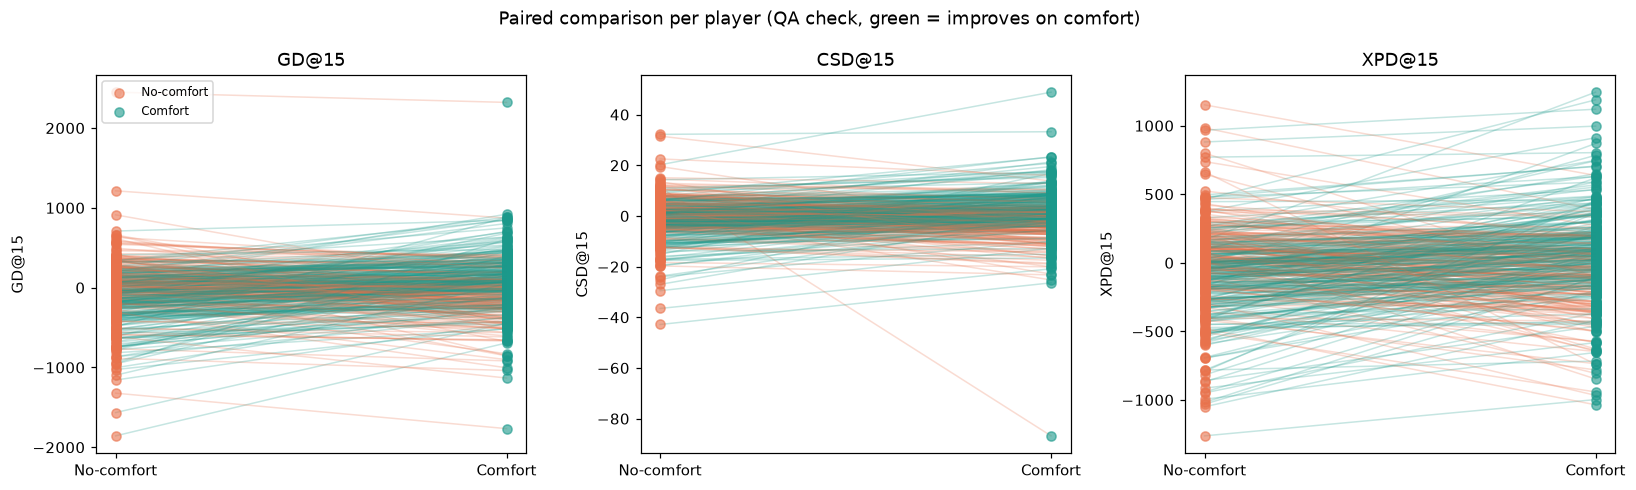

In [45]:
def plot_paired_slope(wide_df: pd.DataFrame, metric: str, label: str, ax):
    comfort_col, nocomfort_col = f"{metric}_comfort", f"{metric}_nocomfort"
    for _, row in wide_df.iterrows():
        color = COLOR_COMFORT if row[comfort_col] > row[nocomfort_col] else COLOR_NOCOMFORT
        ax.plot([0, 1], [row[nocomfort_col], row[comfort_col]], color=color, alpha=0.25, linewidth=1)
    ax.scatter([0] * len(wide_df), wide_df[nocomfort_col], color=COLOR_NOCOMFORT, alpha=0.6, zorder=3, label="No-comfort")
    ax.scatter([1] * len(wide_df), wide_df[comfort_col], color=COLOR_COMFORT, alpha=0.6, zorder=3, label="Comfort")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No-comfort", "Comfort"])
    ax.set_title(label)
    ax.set_ylabel(label)


# Quick QA plot only -- the report-quality version of this figure (Figure 2)
# is built in 04_visuals.ipynb from the CSVs exported above.
n_panels = min(3, len(ALL_METRICS))
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4.5))
axes = np.atleast_1d(axes)
for ax, (metric, label) in zip(axes, list(ALL_METRICS.items())[:n_panels]):
    plot_paired_slope(wide, metric, label, ax)
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Paired comparison per player (QA check, green = improves on comfort)")
fig.tight_layout()
plt.show()

## Part 2 — Linear Mixed Models (LMM)

The paired test in Part 1 collapses all of a player's intra-player variation into a single average and doesn't control for role, side, or opponent strength. The LMM recovers game-by-game granularity and explicitly models the correlation between a player's own games with a **random intercept by player** (`playername`).

**Base model specification** (one per metric):

$$
\text{metric}_{ij} = \beta_0 + \beta_1 \cdot \text{is\_comfort}_{ij} + \beta_2 \cdot \text{position}_{ij} + \beta_3 \cdot \text{side}_{ij} + \beta_4 \cdot \text{elo\_diff\_z}_{ij} + u_j + \varepsilon_{ij}
$$

where $i$ indexes games, $j$ indexes players, $u_j \sim N(0, \tau^2)$ is player $j$'s random intercept, and $\varepsilon_{ij} \sim N(0, \sigma^2)$ is the game-level residual. The coefficient of interest is $\beta_1$: the effect of playing a comfort pick, controlling for role, side and relative opponent strength, **within** each player's own baseline (the random intercept absorbs each player's underlying skill level).

In [46]:
model_df = df.dropna(subset=list(ALL_METRICS) + ["is_comfort", "position", "side", "elo_diff_z", "playername"]).copy()
model_df["is_comfort"] = model_df["is_comfort"].astype(int)
model_df["position"] = model_df["position"].astype("category")
model_df["side"] = model_df["side"].astype(str).str.strip().str.capitalize().astype("category")
model_df["playername"] = model_df["playername"].astype(str)  # redundant safeguard, see the load cell above

print(f"Rows available for the LMM: {len(model_df)} | players: {model_df['playername'].nunique()}")
display(model_df[["is_comfort", "position", "side", "elo_diff_z"]].describe(include="all"))

Rows available for the LMM: 21373 | players: 600


,is_comfort,position,side,elo_diff_z
count,21373.000000,21373,21373,2.137300e+04
unique,NaN,5,2,NaN
top,NaN,sup,Red,NaN
freq,NaN,4340,10695,NaN
mean,0.466009,NaN,NaN,1.446152e-17
std,0.498855,NaN,NaN,1.000000e+00
min,0.000000,NaN,NaN,-4.107193e+00
25%,0.000000,NaN,NaN,-5.960495e-01
50%,0.000000,NaN,NaN,-9.243351e-03
75%,1.000000,NaN,NaN,5.968604e-01


In [1]:
def check_lmm_health(result, metric_label: str) -> bool:
    """
    Lightweight sanity check for a fitted MixedLM result. Flags fits where:
      - the optimizer did not report convergence,
      - the player-level random-intercept variance is ~0 (a classic sign
        of a degenerate / boundary fit), or
      - the random-effects covariance matrix is not full rank (singular),
        which later breaks residual/BLUP extraction.
    Returns True if the fit looks healthy, False otherwise.
    """
    cov_re = np.asarray(result.cov_re)
    group_var = cov_re[0, 0] if cov_re.size else np.nan
    rank_ok = cov_re.size > 0 and np.linalg.matrix_rank(cov_re) == cov_re.shape[0]
    healthy = bool(result.converged) and (group_var == group_var) and group_var > 1e-6 and rank_ok
    if not healthy:
        print(
            f"⚠️ {metric_label}: potentially degenerate fit "
            f"(converged={result.converged}, Group Var={group_var:.6g}, full_rank_cov_re={rank_ok})"
        )
    return healthy


def fit_lmm(data: pd.DataFrame, metric: str, re_formula: str = None):
    """
    Fits a mixed-effects model for `metric` with a random intercept (or,
    if re_formula is given, a random slope) by player. Tries a small chain
    of optimizers/estimation methods and keeps the first attempt that both
    runs without error and passes check_lmm_health(); if none of them look
    healthy, returns the first attempt anyway so the rest of the notebook
    (and the OLS robustness check below) can still flag and work around it.
    """
    formula = f"{metric} ~ is_comfort + C(position) + C(side) + elo_diff_z"
    model = smf.mixedlm(
        formula,
        data=data,
        groups=data["playername"].astype(str),
        re_formula=re_formula,
    )

    attempts = [
        {"reml": True, "method": ["lbfgs"], "maxiter": 300},
        {"reml": True, "method": ["powell"], "maxiter": 1000},
        {"reml": False, "method": ["lbfgs"], "maxiter": 300},
    ]

    first_result = None
    for attempt in attempts:
        try:
            result = model.fit(**attempt)
        except Exception as e:
            print(f"⚠️ {metric}: fit attempt {attempt} raised {type(e).__name__}: {e}")
            continue
        if first_result is None:
            first_result = result
        if check_lmm_health(result, metric):
            return result  # first healthy fit wins
    if first_result is None:
        print(f"⚠️ {metric}: every fit attempt raised an exception; skipping this metric.")
        return None
    print(
        f"⚠️ {metric}: none of the optimizer attempts produced a clearly healthy fit; "
        "returning the first attempt and flagging it for the OLS robustness check below."
    )
    return first_result


def summarize_lmm(result, metric_label: str, data: pd.DataFrame) -> dict:
    coef = result.params.get("is_comfort", np.nan)
    se = result.bse.get("is_comfort", np.nan)
    p = result.pvalues.get("is_comfort", np.nan)
    if "is_comfort" in result.params.index:
        ci_low, ci_high = result.conf_int().loc["is_comfort"]
    else:
        ci_low, ci_high = np.nan, np.nan

    cov_re = np.asarray(result.cov_re)
    var_player = cov_re[0, 0] if cov_re.size else np.nan
    var_resid = result.scale
    icc = var_player / (var_player + var_resid) if var_player == var_player else np.nan

    metric_col = [k for k, v in ALL_METRICS.items() if v == metric_label][0]
    metric_sd = data[metric_col].std()

    return {
        "metric": metric_label,
        "coef_is_comfort": coef,
        "se": se,
        "p_value": p,
        "ci_low": ci_low,
        "ci_high": ci_high,
        # Standardized version (in SDs of the metric), so Figure 1 in
        # 04_visuals.ipynb can compare effects across metrics living on very
        # different scales (gold, CS, KDA, %) without one metric visually
        # dominating the plot just because its raw units happen to be bigger.
        "coef_is_comfort_std": coef / metric_sd if metric_sd else np.nan,
        "ci_low_std": ci_low / metric_sd if metric_sd else np.nan,
        "ci_high_std": ci_high / metric_sd if metric_sd else np.nan,
        "icc_player": icc,
        "n_obs": int(result.nobs),
        "n_players": data["playername"].nunique(),
        "converged": bool(result.converged),
    }

In [48]:
lmm_results = {}
lmm_summary_rows = []

for metric, label in ALL_METRICS.items():
    res = fit_lmm(model_df, metric)
    if res is None:
        continue
    lmm_results[metric] = res
    lmm_summary_rows.append(summarize_lmm(res, label, model_df))

lmm_summary = pd.DataFrame(lmm_summary_rows)
lmm_summary["p_fdr"] = multipletests(lmm_summary["p_value"], alpha=ALPHA, method="fdr_bh")[1]
lmm_summary["significant_fdr"] = lmm_summary["p_fdr"] < ALPHA
display(lmm_summary.round(4).sort_values("p_fdr"))

# --- Early export (Part 2 core outputs) ---
lmm_summary.to_csv(f"{OUT_DIR}/lmm_summary.csv", index=False)
model_df.to_csv(f"{OUT_DIR}/model_df_with_elo.csv", index=False)
print(f"Saved: {OUT_DIR}/lmm_summary.csv")
print(f"Saved: {OUT_DIR}/model_df_with_elo.csv")

if (not lmm_summary["converged"].all()) or (lmm_summary["icc_player"].fillna(0) < 1e-6).any():
    print(
        "\n⚠️ At least one metric produced a degenerate/boundary LMM fit (Group Var ≈ 0) "
        "or failed to converge cleanly. Treat those coefficients with caution and check "
        "the OLS-with-clustered-SEs robustness check further down before reporting them "
        "as your headline result."
    )

⚠️ golddiffat15: potentially degenerate fit (converged=True, Group Var=0, full_rank_cov_re=False)
⚠️ csdiffat15: potentially degenerate fit (converged=True, Group Var=0, full_rank_cov_re=False)
⚠️ xpdiffat15: potentially degenerate fit (converged=True, Group Var=0, full_rank_cov_re=False)
⚠️ dpm: potentially degenerate fit (converged=True, Group Var=0, full_rank_cov_re=False)
⚠️ damageshare: potentially degenerate fit (converged=True, Group Var=0, full_rank_cov_re=False)
⚠️ kda: potentially degenerate fit (converged=True, Group Var=0, full_rank_cov_re=False)


,metric,coef_is_comfort,se,p_value,ci_low,ci_high,coef_is_comfort_std,ci_low_std,ci_high_std,icc_player,n_obs,n_players,converged,p_fdr,significant_fdr
0,GD@15,67.4754,12.1693,0.0000,43.6240,91.3267,0.0776,0.0502,0.1050,0.0552,21373,600,True,0.0000,True
1,CSD@15,1.0878,0.2579,0.0000,0.5824,1.5932,0.0593,0.0317,0.0868,0.0855,21373,600,True,0.0000,True
2,XPD@15,59.9651,10.9628,0.0000,38.4783,81.4519,0.0767,0.0492,0.1042,0.0539,21373,600,True,0.0000,True
5,KDA,0.8976,0.0713,0.0000,0.7579,1.0374,0.1722,0.1454,0.1990,0.0276,21373,600,True,0.0000,True
3,DPM,11.1430,2.9707,0.0002,5.3205,16.9655,0.0388,0.0185,0.0591,0.0722,21373,600,True,0.0002,True
4,DMG%,-0.0537,0.0817,0.5110,-0.2139,0.1065,-0.0059,-0.0234,0.0116,0.0713,21373,600,True,0.5110,False


Saved: data/processed/lmm_summary.csv
Saved: data/processed/model_df_with_elo.csv


### Full summary for one example model

Read this as a diagnostic, not just a results table: look at `Group Var` (should be clearly > 0), whether `Converged` says `Yes`, and whether the standard errors look like ordinary numbers rather than absurdly large or blank — any of those being off is the signature of the degenerate-fit problem described at the top of this notebook.

In [49]:
example_metric = list(ALL_METRICS)[0]
print(f"Full model summary for: {ALL_METRICS[example_metric]}\n")
print(lmm_results[example_metric].summary())

Full model summary for: GD@15

               Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    golddiffat15
No. Observations:    21373      Method:                REML        
No. Groups:          600        Scale:                 690070.4304 
Min. group size:     1          Log-Likelihood:        -174250.4352
Max. group size:     195        Converged:             Yes         
Mean group size:     35.6                                          
-------------------------------------------------------------------
                     Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-------------------------------------------------------------------
Intercept            -12.462   25.508 -0.489 0.625  -62.456  37.533
C(position)[T.jng]     6.494   34.433  0.189 0.850  -60.993  73.981
C(position)[T.mid]   -15.151   34.521 -0.439 0.661  -82.812  52.509
C(position)[T.sup]    23.988   34.545  0.694 0.487  -43.719  91.694
C(position)[T.top]     3.457   3

**Quick diagnostic of the example model.** The LMM assumes normal, homoscedastic residuals $\varepsilon_{ij}$, and normal random effects $u_j$. Metrics like DPM or DMG%, which tend to be right-skewed, are worth checking visually before trusting the p-values at face value.

The cell below is guarded against the singular-covariance crash described at the top of the notebook: if `cov_re` isn't full rank, it falls back to fixed-effects-only residuals instead of raising a `ValueError` and stopping the whole notebook.

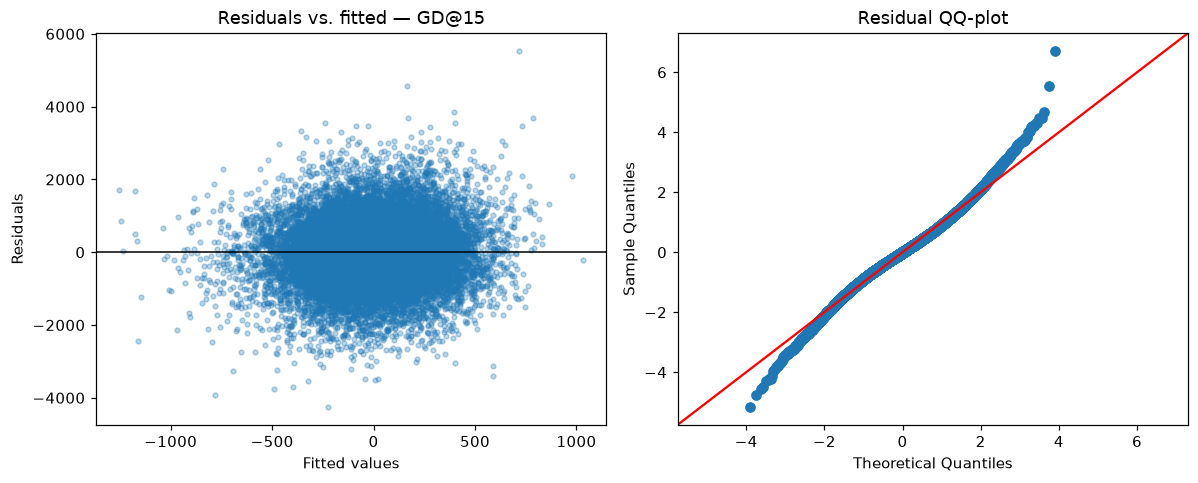

If you see a funnel shape in the left panel or heavy tails in the QQ-plot, consider transforming the metric (e.g. log/sqrt for DPM), or lean on the Part 1 (Wilcoxon) results as your primary evidence instead of the LMM.


In [50]:
example_result = lmm_results[example_metric]
cov_re_example = np.asarray(example_result.cov_re)
is_singular = cov_re_example.size == 0 or np.linalg.matrix_rank(cov_re_example) < cov_re_example.shape[0]

if is_singular:
    print(
        f"⚠️ {ALL_METRICS[example_metric]}: singular random-effects covariance "
        "(BLUPs can't be safely extracted). Falling back to fixed-effects-only "
        "residuals for this diagnostic plot instead of crashing."
    )
    fitted = np.asarray(example_result.model.exog) @ np.asarray(example_result.fe_params)
    resid = model_df[example_metric].to_numpy() - fitted
else:
    resid = example_result.resid
    fitted = example_result.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(fitted, resid, alpha=0.3, s=10)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title(f"Residuals vs. fitted — {ALL_METRICS[example_metric]}")

sm.qqplot(resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Residual QQ-plot")

fig.tight_layout()
plt.show()

print(
    "If you see a funnel shape in the left panel or heavy tails in the QQ-plot, "
    "consider transforming the metric (e.g. log/sqrt for DPM), or lean on the "
    "Part 1 (Wilcoxon) results as your primary evidence instead of the LMM."
)

### Robustness check — OLS with player-clustered standard errors

If the LMM's random-intercept variance for a metric is at (or near) the boundary of the parameter space, statsmodels can't reliably estimate it — the model is *numerically* unstable, which is not the same claim as "there's no real variance between players" (implausible for DPM/KDA, where skill differences are well known to be real).

As a robustness check, we also fit a plain OLS model with the *same* fixed-effects formula, but with standard errors clustered by `playername`. This still respects the fact that a player's games aren't independent observations, without needing to estimate a random-effects variance component at all — it's less elegant than a working LMM, but numerically it can't produce a degenerate fit. If the sign and significance roughly agree between the two, that's good evidence the LMM's point estimate is trustworthy even if its `Group Var` diagnostic looks shaky.

In [51]:
ols_rows = []
for metric, label in ALL_METRICS.items():
    ols_result = smf.ols(
        f"{metric} ~ is_comfort + C(position) + C(side) + elo_diff_z",
        data=model_df,
    ).fit(cov_type="cluster", cov_kwds={"groups": model_df["playername"]})
    coef = ols_result.params["is_comfort"]
    se = ols_result.bse["is_comfort"]
    p = ols_result.pvalues["is_comfort"]
    ci_low, ci_high = ols_result.conf_int().loc["is_comfort"]
    ols_rows.append({
        "metric": label,
        "coef_is_comfort_ols": coef,
        "se_ols": se,
        "p_value_ols": p,
        "ci_low_ols": ci_low,
        "ci_high_ols": ci_high,
    })

ols_robustness = pd.DataFrame(ols_rows)
ols_robustness["p_fdr_ols"] = multipletests(ols_robustness["p_value_ols"], alpha=ALPHA, method="fdr_bh")[1]
display(ols_robustness.round(4))

comparison = lmm_summary[["metric", "coef_is_comfort", "p_fdr", "converged"]].merge(
    ols_robustness[["metric", "coef_is_comfort_ols", "p_fdr_ols"]], on="metric"
)
print("\nLMM vs. OLS-clustered comparison (do sign and significance roughly agree?):")
display(comparison.round(4))

ols_robustness.to_csv(f"{OUT_DIR}/ols_robustness_check.csv", index=False)
print(f"Saved: {OUT_DIR}/ols_robustness_check.csv")

,metric,coef_is_comfort_ols,se_ols,p_value_ols,ci_low_ols,ci_high_ols,p_fdr_ols
0,GD@15,63.0438,14.6700,0.0000,34.2912,91.7965,0.0001
1,CSD@15,1.0524,0.3513,0.0027,0.3637,1.7410,0.0041
2,XPD@15,55.0009,13.7369,0.0001,28.0771,81.9246,0.0001
3,DPM,6.5941,4.4032,0.1342,-2.0360,15.2243,0.1611
4,DMG%,-0.1075,0.1191,0.3668,-0.3410,0.1260,0.3668
5,KDA,0.9103,0.0834,0.0000,0.7469,1.0737,0.0000



LMM vs. OLS-clustered comparison (do sign and significance roughly agree?):


,metric,coef_is_comfort,p_fdr,converged,coef_is_comfort_ols,p_fdr_ols
0,GD@15,67.4754,0.0000,True,63.0438,0.0001
1,CSD@15,1.0878,0.0000,True,1.0524,0.0041
2,XPD@15,59.9651,0.0000,True,55.0009,0.0001
3,DPM,11.1430,0.0002,True,6.5941,0.1611
4,DMG%,-0.0537,0.5110,True,-0.1075,0.3668
5,KDA,0.8976,0.0000,True,0.9103,0.0000


Saved: data/processed/ols_robustness_check.csv


### Extension — is the comfort effect the same for every player?

The model above assumes a single $\beta_1$ (comfort effect) for the whole league. That's a strong assumption: it's reasonable to expect the "comfort bonus" to be larger for players with deeper champion pools, or basically irrelevant for others. To quantify this heterogeneity, we add a **random slope** for `is_comfort` by player:

$$
\text{metric}_{ij} = \beta_0 + \beta_1 \cdot \text{is\_comfort}_{ij} + \dots + u_{0j} + u_{1j} \cdot \text{is\_comfort}_{ij} + \varepsilon_{ij}
$$

$u_{1j}$ is player $j$'s deviation from the average effect $\beta_1$. With the BLUP (*Best Linear Unbiased Predictor*) estimates of $u_{1j}$, we can rank which players benefit most (or least) from their comfort picks — the kind of insight a coaching staff can directly act on.

**Shrinkage warning:** BLUPs are shrunk toward the mean more strongly the fewer games a player has. Don't read them as a final ranking without also looking at `n_games` per player.

In [52]:
primary_metric = "golddiffat15" if "golddiffat15" in ALL_METRICS else list(ALL_METRICS)[0]
random_slope_result = fit_lmm(model_df, primary_metric, re_formula="~is_comfort")

re_df = None
if random_slope_result is not None:
    print(random_slope_result.summary())
    healthy = check_lmm_health(random_slope_result, f"{ALL_METRICS[primary_metric]} (random slope)")
    if not healthy:
        print(
            "⚠️ The random-slope model looks unstable too. Treat the BLUP ranking below as "
            "exploratory, not as a reliable coaching deliverable, until the underlying LMM "
            "convergence issue is resolved (see the OLS robustness check above)."
        )

    re_raw = pd.DataFrame(random_slope_result.random_effects).T
    if re_raw.shape[1] == 2:
        re_df = re_raw.copy()
        re_df.columns = ["u0_intercept", "u1_is_comfort_slope"]
    else:
        print(f"⚠️ Unexpected random_effects columns ({re_raw.columns.tolist()}); check re_formula.")
        re_df = re_raw
        re_df["u1_is_comfort_slope"] = re_df.iloc[:, -1]

    re_df["comfort_effect_player"] = random_slope_result.fe_params["is_comfort"] + re_df["u1_is_comfort_slope"]

    n_games_by_player = model_df.groupby("playername")["gameid"].nunique().rename("n_games_total")
    re_df = re_df.join(n_games_by_player)

    print(f"\nTop 10 players with the largest estimated comfort effect on {ALL_METRICS[primary_metric]}:")
    display(re_df.sort_values("comfort_effect_player", ascending=False).head(10).round(2))

    print("\nBottom 10 players (smallest or negative estimated comfort effect):")
    display(re_df.sort_values("comfort_effect_player", ascending=True).head(10).round(2))

    # --- Early export (Part 2 extension) ---
    primary_pos = (
        model_df.groupby("playername")["position"]
        .agg(lambda s: s.mode().iloc[0] if not s.empty else "unknown")
        .rename("position")
    )
    re_export = re_df.reset_index().rename(columns={"index": "playername"})
    re_export = re_export.merge(primary_pos, on="playername", how="left")
    re_export["metric"] = ALL_METRICS[primary_metric]
    try:
        re_export.to_csv(f"{OUT_DIR}/comfort_effect_by_player.csv", index=False)
        print(f"Saved: {OUT_DIR}/comfort_effect_by_player.csv")
    except Exception as e:
        print(f"⚠️ Could not export comfort_effect_by_player.csv: {e}")
else:
    print(
        f"⚠️ Could not fit the random-slope model for {ALL_METRICS[primary_metric]}; "
        "Figures 3 and 4 in 04_visuals.ipynb will have no data to plot until this is resolved."
    )

                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     golddiffat15
No. Observations:       21373       Method:                 REML        
No. Groups:             600         Scale:                  687085.6646 
Min. group size:        1           Log-Likelihood:         -174239.8483
Max. group size:        195         Converged:              Yes         
Mean group size:        35.6                                            
------------------------------------------------------------------------
                         Coef.    Std.Err.   z    P>|z|  [0.025   0.975]
------------------------------------------------------------------------
Intercept                  -7.786   25.465 -0.306 0.760  -57.697  42.125
C(position)[T.jng]         -0.067   33.445 -0.002 0.998  -65.618  65.483
C(position)[T.mid]        -20.241   33.619 -0.602 0.547  -86.134  45.652
C(position)[T.sup]          6.665   33.981  0.196 0.844  -59.936  73.

,u0_intercept,u1_is_comfort_slope,comfort_effect_player,n_games_total
adrianlaneitor,-731.57,265.35,342.19,20
Notiko,-306.05,185.47,262.31,21
Dreilix,-378.17,171.27,248.11,30
Zilax,-432.66,156.93,233.77,8
selenex,-321.67,152.69,229.52,53
Send0o,-340.87,144.71,221.55,36
Berone,-379.03,137.48,214.32,6
Afroboi,59.69,137.37,214.21,131
NightSlayer,20.04,136.07,212.90,83
Scuffed,-418.24,134.50,211.33,39



Bottom 10 players (smallest or negative estimated comfort effect):


,u0_intercept,u1_is_comfort_slope,comfort_effect_player,n_games_total
Yakkey,909.45,-243.70,-166.86,8
NuQ,652.55,-236.69,-159.85,37
Zest,493.03,-214.58,-137.74,31
Rabble,330.89,-197.47,-120.64,103
Tracyn,417.03,-182.84,-106.00,72
Daglas,218.45,-182.34,-105.50,97
Irrelevant,358.74,-177.13,-100.29,88
Sayn,480.97,-162.19,-85.35,16
Ronaldo,468.71,-160.81,-83.97,44
Neon,408.12,-150.16,-73.32,57


Saved: data/processed/comfort_effect_by_player.csv


### Optional robustness — nesting by team

The "real" hierarchy in this data has 3 levels: games nested in players nested in teams (teammates share a coaching staff, scrims, and draft context). `MixedLM` doesn't directly support 3 nested levels via the `groups=` argument, but it can be approximated with **variance components** (`vc_formula`), keeping `playername` as the primary grouping variable and adding a variance component for `teamname`:

**Heads up before you run this:** because each player belongs to exactly one team, the team-level variance component and the player-level random intercept are only weakly separable unless each team contributes many sampled players -- with a typical roster (~5 starters per team), this is a genuine identification problem, not just a convergence quirk. It's common (and fine) for this cell to report a degenerate team variance; the guarded code below checks for that explicitly and prints a clear message instead of surfacing statsmodels' internal `RuntimeWarning`s about it.


In [53]:
vc = {"team": "0 + C(teamname)"}
try:
    nested_model = smf.mixedlm(
        f"{primary_metric} ~ is_comfort + C(position) + C(side) + elo_diff_z",
        data=model_df,
        groups=model_df["playername"].astype(str),
        vc_formula=vc,
    )
    # The optimizer routinely probes near-zero variance-component values
    # while it searches (very likely here: each player belongs to exactly
    # one team, so the "team" variance component is largely confounded
    # with the player-level random intercept unless teams have many
    # sampled players each -- with ~5 starters per team this is a genuine
    # identification problem, not just an optimizer quirk). That produces
    # a wall of harmless-but-noisy RuntimeWarnings ("divide by zero
    # encountered in log", etc.) from statsmodels' internal solver while
    # it explores the boundary. We suppress those locally (only for this
    # one fit) and check the health of the *final* result explicitly
    # instead of reading anything into the intermediate warnings.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        nested_result = nested_model.fit(reml=True, method=["lbfgs"], maxiter=300)

    team_var = float(nested_result.vcomp[0]) if len(nested_result.vcomp) else np.nan
    team_var_ok = np.isfinite(team_var) and team_var > 1e-6
    if (not nested_result.converged) or not team_var_ok:
        print(
            f"⚠️ Nested (by-team) model: the team-level variance component looks "
            f"degenerate (converged={nested_result.converged}, team Var={team_var:.6g}). "
            "This is the expected outcome with only a handful of players per team -- "
            "there usually isn't enough within-team replication to separate a team "
            "effect from the player-level random intercept. Treat this cell as an "
            "attempted robustness check, not as a result to report; it's fine to "
            "state in your README that you tried it and found it unidentifiable "
            "at this sample size."
        )
    else:
        print(nested_result.summary())
except Exception as e:
    print(
        "The nested model didn't converge with this specification "
        f"({e}). This is expected with few teams / few players per team; "
        "treat it as optional robustness, not as the headline model to report."
    )

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     golddiffat15
No. Observations:     21373       Method:                 REML        
No. Groups:           600         Scale:                  651595.8292 
Min. group size:      1           Log-Likelihood:         -175804.1248
Max. group size:      195         Converged:              Yes         
Mean group size:      35.6                                            
----------------------------------------------------------------------
                      Coef.     Std.Err.   z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------
Intercept              -126.257  198.396 -0.636 0.525 -515.105 262.591
C(position)[T.jng]       50.474  264.714  0.191 0.849 -468.356 569.304
C(position)[T.mid]       72.252  240.037  0.301 0.763 -398.212 542.715
C(position)[T.sup]      282.669  264.723  1.068 0.286 -236.178 801.517
C(position)[T.top]     

## Part 3 — Selection bias and endogeneity in comfort-pick assignment

Before interpreting any coefficient from the sections above as anything close to a causal effect, it's worth being upfront about the design: **`is_comfort` is not a randomly assigned treatment.**

### 3.1 — Why this is "confounding by indication"

A comfort pick is chosen *precisely because* the coaching staff expects it to work well in that context: against that opponent, at that point in the draft, at that moment of the series. This is analogous to "confounding by indication" in observational medical studies, where a treatment is prescribed more often to patients who already have a better prognosis. If the assignment mechanism is correlated with the outcome, any raw comparison between groups conflates the effect of the "treatment" with the effect of the selection criterion itself.

Concrete sources of confounding in this dataset:

1. **Relative team strength.** Favored teams can afford to give their star player comfort in games they already dominate in draft or overall strength — `elo_diff_z` (Part 2) partially controls for this, but it isn't information the player had *before* the draft in the same causal sense.
2. **Draft phase (blind vs. counter-pick).** A comfort pick locked in during blind phase (rounds 1-2) carries more counter-pick risk than an assigned pick chosen in the last rotation specifically to counter the opponent. This dataset doesn't distinguish pick/ban order — a variable worth adding if your Oracle's Elixir download includes it (columns like `pick1`...`pick5`), or via the Leaguepedia Cargo API for full draft-order data.
3. **Champion power in the current patch (meta strength).** If a player's "comfort" champion happens to be strong in the current patch, the model attributes that performance to "comfort" when it's really raw champion power. This is probably the most important missing confounder: ideally it should be controlled with a player-independent measure of champion strength (global win rate/pick rate on that patch, or a crossed random effect by champion).
4. **Series stakes / moment.** A Bo1 in the group stage and a Bo5 grand final don't create the same incentives to risk (or avoid) an off-meta comfort pick.

### 3.2 — What the current design does (and doesn't) fix

- The random intercept by player in the LMM absorbs each player's baseline skill — the `is_comfort` effect is no longer contaminated by "better players tend to have more comfort picks," because it's estimated **within** each player (intra-subject variation).
- `elo_diff_z` controls for observable relative opponent strength at the time of the game.
- What it **doesn't** fix: time-varying confounders within the same player that are correlated with the decision to draft comfort (champion power on the current patch, draft phase, series stakes).

### 3.3 — How to keep reducing the bias (roadmap, not implemented in this notebook)

- **Control for champion strength:** add global win rate/pick rate for the champion on that patch (or a crossed random effect by champion) to the LMM formula.
- **Matching / propensity-score weighting:** match comfort and no-comfort games on `elo_diff`, `side`, `playoffs` and patch, to compare similar contexts before averaging.
- **Difference-in-differences design:** exploit patch nerfs/buffs that force a player to drop (or let them return to) a comfort pick as a natural quasi-experiment.
- **Sensitivity analysis (Rosenbaum bounds):** quantify how much unobserved confounding would be needed to nullify the estimated effect — useful for honestly reporting how fragile (or robust) the result is.
- **Restrict to comparable subgroups:** repeat the analysis only on games against similarly-rated opponents, at the cost of sample size.

### 3.4 — Empirical check: does comfort correlate with context?

Instead of staying purely in theoretical discussion, we can test directly whether the probability that a game is "comfort" depends on available context variables (`elo_diff_z`, `side`, `position`). If the `elo_diff_z` coefficient turns out significant, that's direct evidence that comfort **is not assigned at random with respect to relative opponent strength** — empirically confirming the theoretical concern above.

In [54]:
logit_formula = "is_comfort ~ elo_diff_z + C(position) + C(side)"
logit_model = smf.logit(logit_formula, data=model_df).fit(disp=0)
print(logit_model.summary())

odds_ratios = np.exp(logit_model.params).rename("odds_ratio")
ci = np.exp(logit_model.conf_int())
ci.columns = ["ci_low", "ci_high"]
logit_summary = pd.concat([odds_ratios, ci, logit_model.pvalues.rename("p_value")], axis=1).round(4)
display(logit_summary)

logit_summary.reset_index().rename(columns={"index": "term"}).to_csv(
    f"{OUT_DIR}/selection_bias_logit_summary.csv", index=False
)
print(f"Saved: {OUT_DIR}/selection_bias_logit_summary.csv")

                           Logit Regression Results                           
Dep. Variable:             is_comfort   No. Observations:                21373
Model:                          Logit   Df Residuals:                    21366
Method:                           MLE   Df Model:                            6
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                0.008193
Time:                        04:01:43   Log-Likelihood:                -14644.
converged:                       True   LL-Null:                       -14765.
Covariance Type:            nonrobust   LLR p-value:                 2.153e-49
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0391      0.034     -1.156      0.248      -0.106       0.027
C(position)[T.jng]     0.0320      0.044      0.732      0.464      -0.054       0.118
C(position)[T.mid]  

,odds_ratio,ci_low,ci_high,p_value
Intercept,0.9616,0.8999,1.0276,0.2478
C(position)[T.jng],1.0325,0.9477,1.1249,0.4643
C(position)[T.mid],0.8743,0.8023,0.9527,0.0022
C(position)[T.sup],1.1151,1.0241,1.2142,0.0121
C(position)[T.top],0.8997,0.8259,0.9800,0.0154
C(side)[T.Red],0.8540,0.8090,0.9014,0.0000
elo_diff_z,1.1954,1.1632,1.2286,0.0000


Saved: data/processed/selection_bias_logit_summary.csv


**How to read this:** if the `elo_diff_z` coefficient is different from zero with significance (especially if the odds ratio is clearly away from 1), you have direct — not just theoretical — evidence that relative team strength predicts whether a game ends up being comfort or not. That validates the concern in Section 3.1: the opponent-strength proxy you included as a "control" in the LMM is also, in part, a **cause** of `is_comfort`, not just an independent confounder. This doesn't invalidate the LMM, but it does mean comfort's $\beta_1$ should be reported as an *adjusted association*, not a causal effect, unless you apply one of the strategies in Section 3.3.

## Summary and next steps

- **Part 1** gives a first robust (non-parametric) signal per metric, at player level, with multiple-comparison correction.
- **Part 2** recovers game-by-game granularity, controls for role/side/opponent strength, quantifies how much heterogeneity exists across players in the comfort effect, and — new in this version — cross-checks the LMM against an OLS-with-clustered-SEs model whenever the random-intercept variance looks unstable.
- **Part 3** documents — and partially verifies empirically — the main threat to this analysis' causal validity: comfort is not assigned at random.

**Outputs produced by this notebook** (all saved incrementally, right after being computed, in `data/processed/`):

| File | Content | Used in |
|---|---|---|
| `paired_test_results.csv` | Paired Wilcoxon / t-test per metric (Part 1) | Fig. 2 |
| `player_comfort_means_wide.csv` | Per-player comfort / no-comfort means (Part 1) | Fig. 2 |
| `lmm_summary.csv` | LMM `is_comfort` coefficient per metric, raw + standardized, with 95% CI (Part 2) | Fig. 1 |
| `ols_robustness_check.csv` | OLS-with-clustered-SEs companion estimates (Part 2) | robustness appendix |
| `comfort_effect_by_player.csv` | BLUP heterogeneity ranking of the comfort effect by player (Part 2 extension) | Fig. 3, Fig. 4 |
| `model_df_with_elo.csv` | Player-game data with `elo_diff_z` (Part 0) | Fig. 5 |
| `selection_bias_logit_summary.csv` | Logistic regression of the selection-bias check (Part 3.4) | supporting text |

**Next notebook (`04_visuals.ipynb`):** turn `paired_results`, `lmm_summary` and the `comfort_effect_by_player` ranking into figures for the README / portfolio (forest plot of standardized coefficients per metric, distribution of `comfort_effect_player` by role, etc.).

**Future extensions outside this notebook:**
- A Win Rate (binary outcome) model via GEE or a Bayesian Mixed GLM (`statsmodels.genmod.bayes_mixed_glm.BinomialBayesMixedGLM`).
- Controlling for champion strength on the current patch (global win rate/pick rate).
- Propensity-score matching before the paired comparison in Part 1.